In [31]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt

Exercise 2.1

Optimal polynomial: 2.0296 + -0.0483x + 5.0186x^2


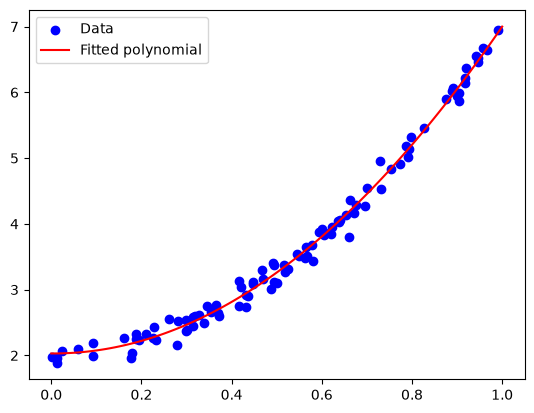

In [32]:
rng = np.random.default_rng(2026)
x = rng.random((100, 1)) 
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

X = np.linspace(0, 1, 100)

x_matrix = np.vander(x.flatten(), 3, increasing=True)

# Bruker least squares for å finne koeffisientene
B = np.linalg.inv(x_matrix.T @ x_matrix) @ x_matrix.T @ y
B = B.flatten().round(4)

print(f'Optimal polynomial: {B[0]} + {B[1]}x + {B[2]}x^2')

plt.scatter(x, y, label='Data', color='blue')
plt.plot(X, B[0] + B[1] * X + B[2] * X**2, label='Fitted polynomial', color='red')
plt.legend()
plt.show()

Exercise 2.2

Intercept: [2.0296]


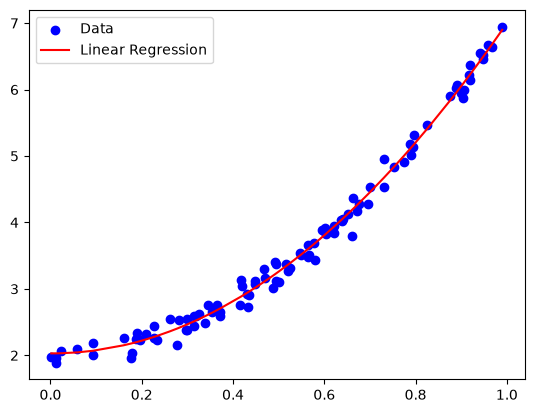

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Kan bruke np vander matrisen istedenfor PolynomialFeatures
model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
model.fit(x, y)

model_intercept = model.named_steps['linearregression'].intercept_
print(f'Intercept: {model_intercept.flatten().round(4)}')

y_pred = model.predict(x)

order = np.argsort(x.flatten())

plt.scatter(x, y, label='Data', color='blue')
plt.plot(x.flatten()[order], y_pred.flatten()[order], label='Linear Regression', color='red')
plt.legend()
plt.show()

Exercise 2.3

In [34]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')

r2_score = r2_score(y, y_pred)
print(f'R^2 Score: {r2_score}')

Mean Squared Error: 0.013728156746263003
R^2 Score: 0.9928732429893427


Exercise 3

Train Mean Squared Error: 0.030238424439200905
Test Mean Squared Error: 0.03613895070529331
Train Mean Squared Error: 0.024587742949002372
Test Mean Squared Error: 0.027738042378967192
Train Mean Squared Error: 0.01943103901034383
Test Mean Squared Error: 0.02346938551139318
Train Mean Squared Error: 0.01435798319813747
Test Mean Squared Error: 0.02542697452699383
Train Mean Squared Error: 0.00966198141157741
Test Mean Squared Error: 0.01620259370790552
Train Mean Squared Error: 0.009640915046612065
Test Mean Squared Error: 0.016527427048130306
Train Mean Squared Error: 0.008344692022676833
Test Mean Squared Error: 0.019623832525139818
Train Mean Squared Error: 0.007337133424837781
Test Mean Squared Error: 0.01388586203513675
Train Mean Squared Error: 0.009977450950479529
Test Mean Squared Error: 0.020705419185682174
Train Mean Squared Error: 0.018310848441496934
Test Mean Squared Error: 0.030303960702576987


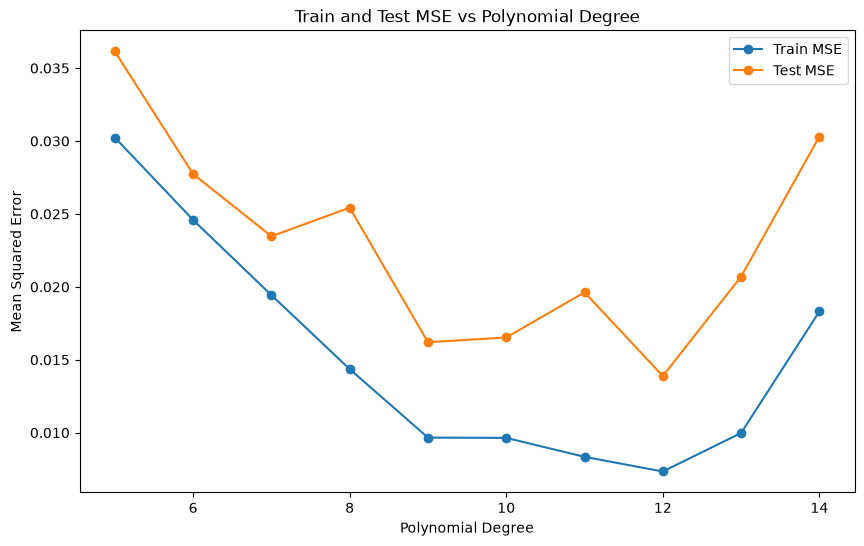

In [46]:
from sklearn.model_selection import train_test_split

n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

train_mse_list = []
test_mse_list = []

for degree in range(5, 15):
    X = np.vander(x.flatten(), degree, increasing=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f'Train Mean Squared Error: {train_mse}')
    print(f'Test Mean Squared Error: {test_mse}')

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)


plt.figure(figsize=(10, 6))
plt.plot(range(5, 15), train_mse_list, label='Train MSE', marker='o')
plt.plot(range(5, 15), test_mse_list, label='Test MSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Train and Test MSE vs Polynomial Degree')
plt.legend()
plt.show()